# Breast Cancer Subtype Prediction
# Step 4: Feature Selection - Phase 2 (ANOVA / F-test)
# Goal: Select top 500 features for RNA and Methylation based on statistical significance.

## Import Libraries

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, accuracy_score
from src.utils import load_object, save_object, plot_confusion_matrix

print('✅ Libraries & Utilities Imported (including pickle).')

✅ Libraries & Utilities Imported (including pickle).


## Define IO Functions

In [2]:
# IO handled by src.utils
print('✅ IO ready.')

✅ IO ready.


## Load Data (From Step 1 - Variance Threshold)


In [3]:
print("Loading variance-filtered data from '../outputs/'...")

try:
    X_train_rna = load_object('X_train_rna_var')
    X_test_rna = load_object('X_test_rna_var')
    feat_indices_rna_var = load_object('feat_indices_rna_var')
    feat_names_rna_var = load_object('feat_names_rna_var')
    
    X_train_meth = load_object('X_train_meth_var')
    X_test_meth = load_object('X_test_meth_var')
    feat_indices_meth_var = load_object('feat_indices_meth_var')
    feat_names_meth_var = load_object('feat_names_meth_var')
    
    y_train = load_object('y_train')
    y_test = load_object('y_test')
    
    print("\nData Loaded Successfully.")
    print(f"RNA Inputs: {X_train_rna.shape}")
    print(f"Methylation Inputs: {X_train_meth.shape}")
except FileNotFoundError:
    print("❌ Error: Files not found. Run Feature Selection Step 1 first.")

Loading variance-filtered data from '../outputs/'...



Data Loaded Successfully.
RNA Inputs: (439, 16124)
Methylation Inputs: (439, 16085)


## 1. ANOVA on RNA-Seq


In [4]:
K_RNA = 500
print(f"Selecting Top {K_RNA} RNA Features using ANOVA F-test...")

selector_rna = SelectKBest(score_func=f_classif, k=K_RNA)
X_train_rna_anova = selector_rna.fit_transform(X_train_rna, y_train)
X_test_rna_anova = selector_rna.transform(X_test_rna)

selected_indices_local = selector_rna.get_support(indices=True)
final_rna_indices = feat_indices_rna_var[selected_indices_local]
final_rna_names = [feat_names_rna_var[i] for i in selected_indices_local]

print(f"✅ RNA Selection Done. Shape: {X_train_rna_anova.shape}")

Selecting Top 500 RNA Features using ANOVA F-test...
✅ RNA Selection Done. Shape: (439, 500)


## 2. ANOVA on Methylation


In [5]:
K_METH = 500
print(f"Selecting Top {K_METH} Methylation Features using ANOVA F-test...")

selector_meth = SelectKBest(score_func=f_classif, k=K_METH)
X_train_meth_anova = selector_meth.fit_transform(X_train_meth, y_train)
X_test_meth_anova = selector_meth.transform(X_test_meth)

selected_indices_local_meth = selector_meth.get_support(indices=True)
final_meth_indices = feat_indices_meth_var[selected_indices_local_meth]
final_meth_names = [feat_names_meth_var[i] for i in selected_indices_local_meth]

print(f"✅ Methylation Selection Done. Shape: {X_train_meth_anova.shape}")

Selecting Top 500 Methylation Features using ANOVA F-test...
✅ Methylation Selection Done. Shape: (439, 500)


## Validation: LDA with Top 1000 Features


Validating ANOVA Feature Selection using 5-Fold CV on TRAINING DATA ONLY...
(X_test is strictly preserved as a fresh holdout and NOT evaluated here)



5-Fold Training CV Accuracy (Top 1000 ANOVA Features): 88.61%
              precision    recall  f1-score   support

        LumA       0.89      0.92      0.90       237
        LumB       0.78      0.71      0.74        97
        Her2       0.93      0.89      0.91        28
       Basal       1.00      0.99      0.99        77

    accuracy                           0.89       439
   macro avg       0.90      0.88      0.89       439
weighted avg       0.88      0.89      0.88       439



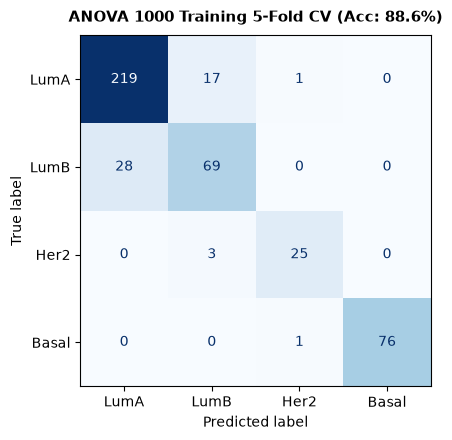


Generating sensitivity curve of CV Accuracy vs. k (ANOVA)...


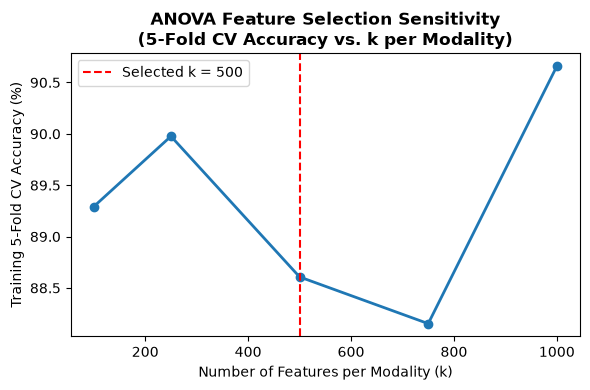

In [6]:
print('Validating ANOVA Feature Selection using 5-Fold CV on TRAINING DATA ONLY...')
print('(X_test is strictly preserved as a fresh holdout and NOT evaluated here)')

X_train_combined = np.hstack((X_train_rna_anova, X_train_meth_anova))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')

oof_preds = cross_val_predict(lda, X_train_combined, np.asarray(y_train).ravel(), cv=cv)
cv_acc = accuracy_score(np.asarray(y_train).ravel(), oof_preds)
target_names = ['LumA', 'LumB', 'Her2', 'Basal']

print(f'\n5-Fold Training CV Accuracy (Top 1000 ANOVA Features): {cv_acc*100:.2f}%')
print(classification_report(np.asarray(y_train).ravel(), oof_preds, target_names=target_names))

fig, ax = plot_confusion_matrix(y_train, oof_preds, target_names, f'ANOVA 1000 Training 5-Fold CV (Acc: {cv_acc*100:.1f}%)')
plt.show()

# Sensitivity Analysis: Empirical justification of K=500 per modality
print('\nGenerating sensitivity curve of CV Accuracy vs. k (ANOVA)...')
k_candidates = [100, 250, 500, 750, 1000]
k_accs = []
y_tr_arr = np.asarray(y_train).ravel()
for k_cand in k_candidates:
    s_r = SelectKBest(f_classif, k=k_cand).fit_transform(X_train_rna, y_tr_arr)
    s_m = SelectKBest(f_classif, k=k_cand).fit_transform(X_train_meth, y_tr_arr)
    s_comb = np.hstack((s_r, s_m))
    lda_k = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
    fold_scores = [lda_k.fit(s_comb[t], y_tr_arr[t]).score(s_comb[v], y_tr_arr[v]) for t, v in cv.split(s_comb, y_tr_arr)]
    k_accs.append(np.mean(fold_scores))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(k_candidates, [s * 100 for s in k_accs], marker='o', color='#1f77b4', linewidth=2)
ax.axvline(x=500, color='red', linestyle='--', label='Selected k = 500')
ax.set_title('ANOVA Feature Selection Sensitivity\n(5-Fold CV Accuracy vs. k per Modality)', fontweight='bold')
ax.set_xlabel('Number of Features per Modality (k)')
ax.set_ylabel('Training 5-Fold CV Accuracy (%)')
ax.legend()
plt.tight_layout()
plt.show()

## Saving Result


In [7]:
print('Saving ANOVA selected datasets to ../outputs/...')

save_object(X_train_rna_anova, 'X_train_rna_anova')
save_object(X_test_rna_anova,  'X_test_rna_anova')
save_object(final_rna_indices, 'feat_indices_rna_anova')
save_object(final_rna_names, 'feat_names_rna_anova')

save_object(X_train_meth_anova, 'X_train_meth_anova')
save_object(X_test_meth_anova,  'X_test_meth_anova')
save_object(final_meth_indices, 'feat_indices_meth_anova')
save_object(final_meth_names, 'feat_names_meth_anova')

save_object(y_train, 'y_train')
save_object(y_test,  'y_test')

print('\n🎉 Feature Selection Step 2 (ANOVA) Completed.')

Saving ANOVA selected datasets to '../outputs/'...
💾 Saved: ../outputs\X_train_rna_anova.npz (+ .pkl)
💾 Saved: ../outputs\X_test_rna_anova.npz (+ .pkl)
💾 Saved: ../outputs\feat_indices_rna_anova.npz (+ .pkl)
💾 Saved: ../outputs\feat_names_rna_anova.pkl
💾 Saved: ../outputs\X_train_meth_anova.npz (+ .pkl)
💾 Saved: ../outputs\X_test_meth_anova.npz (+ .pkl)
💾 Saved: ../outputs\feat_indices_meth_anova.npz (+ .pkl)
💾 Saved: ../outputs\feat_names_meth_anova.pkl
💾 Saved: ../outputs\y_train.parquet (+ .pkl)
💾 Saved: ../outputs\y_test.parquet (+ .pkl)

🎉 Feature Selection Step 2 (ANOVA) Completed.
